In [93]:
#
# Solve the TSPN adapted from MATLAB code
#

import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from pykml import parser
from matplotlib import path

lat_eNBs = [35.7275, 35.728056, 35.725, 35.733056]
lon_eNBs = [-78.695833, -78.700833, -78.691667, -78.698333]
alt_eNBs = [10, 10, 10, 10] # altitudes for eNodeBs
r_eNBs = [0.0006, 0.0006, 0.0008, 0.0035] #Radius for eNobeB neighborhoods
colors = ["m", "g", "b", "r"]


In [ ]:
def inpolygon(xq, yq, xv, yv):
    #shape = xq.shape
    #xq = xq.reshape(-1)
    #yq = yq.reshape(-1)
    xv = xv.reshape(-1)
    yv = yv.reshape(-1)
    q = [(xq[i], yq[i]) for i in range(xq.shape[0])]
    p = path.Path([(xv[i], yv[i]) for i in range(xv.shape[0])])
    return p.contains_points(q).reshape(shape)

In [17]:
with open('UAVFlexSimFramework-main\Autonomous Trajectory\AERPAW_UAV_Geofence_Phase_1.kml', 'r', encoding="utf-8") as f:
   root = parser.parse(f).getroot()

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\kherm\AppData\Local\Temp\ipykernel_87468\617182431.py:1: SyntaxWarning: invalid escape sequence '\A'
  with open('UAVFlexSimFramework-main\Autonomous Trajectory\AERPAW_UAV_Geofence_Phase_1.kml', 'r', encoding="utf-8") as f:


In [52]:
coords = root.Document.Placemark.Polygon.outerBoundaryIs.LinearRing.coordinates
lonlatel = coords.text.strip().split(' ')
#print(lonlatel)
geofence_lon = []
geofence_lat = []
for xyz in lonlatel:
    lon, lat, _ = xyz.split(',')
    geofence_lon.append(float(lon))
    geofence_lat.append(float(lat))

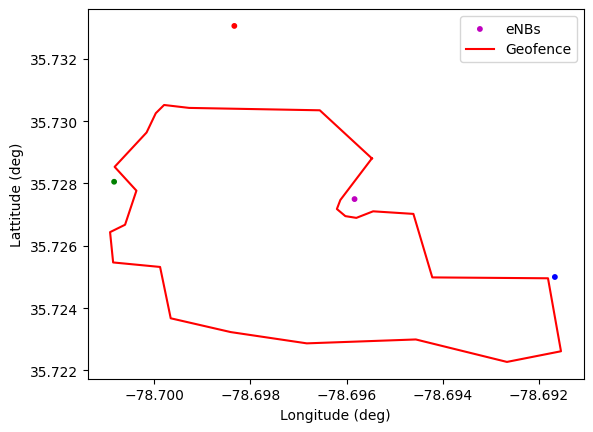

In [68]:
plt.scatter(lon_eNBs, lat_eNBs, 10*np.ones((1,len(lon_eNBs))),colors)
plt.plot(geofence_lon, geofence_lat, 'r-')
plt.xlabel('Longitude (deg)')
plt.xlabel('Longitude (deg)')
plt.ylabel('Lattitude (deg)')
plt.legend(['eNBs', 'Geofence'])
plt.show()

In [95]:
geofence_lon  = np.reshape(np.array(geofence_lon), (-1,1))
geofence_lat  = np.reshape(np.array(geofence_lat), (-1,1))

geo_poly = np.concatenate((geofence_lon, geofence_lat),axis=1)
print(inpolygon(lon_eNBs[0], lat_eNBs[0], geofence_lon, geofence_lat))

AttributeError: 'float' object has no attribute 'shape'